<a href="https://colab.research.google.com/github/asadarfaat97-byte/Arafat-shaikh/blob/main/proj2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [68]:
import pandas as pd
import matplotlib.pyplot as plt

In [69]:
import pandas as pd

# Read the first few lines of the file to inspect its content
with open('city_day.csv', 'r') as f:
    for i, line in enumerate(f):
        print(line.strip())
        if i >= 4: # Print first 5 lines
            break

City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
Ahmedabad,2015-01-01,,,0.92,18.22,17.15,,0.92,27.64,133.36,0.0,0.02,0.0,,
Ahmedabad,2015-01-02,,,0.97,15.69,16.46,,0.97,24.55,34.06,3.68,5.5,3.77,,
Ahmedabad,2015-01-03,,,17.4,19.3,29.7,,17.4,29.07,30.7,6.8,16.4,2.25,,
Ahmedabad,2015-01-04,,,1.7,18.48,17.97,,1.7,18.59,36.08,4.43,10.14,1.0,,


In [70]:
print(df.shape)

print(df.info())

print(df.isnull().sum())

(29531, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   City        29531 non-null  object        
 1   Date        29531 non-null  datetime64[ns]
 2   PM2.5       24933 non-null  float64       
 3   PM10        18391 non-null  float64       
 4   NO          25949 non-null  float64       
 5   NO2         25946 non-null  float64       
 6   NOx         25346 non-null  float64       
 7   NH3         19203 non-null  float64       
 8   CO          27472 non-null  float64       
 9   SO2         25677 non-null  float64       
 10  O3          25509 non-null  float64       
 11  Benzene     23908 non-null  float64       
 12  Toluene     21490 non-null  float64       
 13  Xylene      11422 non-null  float64       
 14  AQI         24850 non-null  float64       
 15  AQI_Bucket  24850 non-null  object        
dtypes: datetim

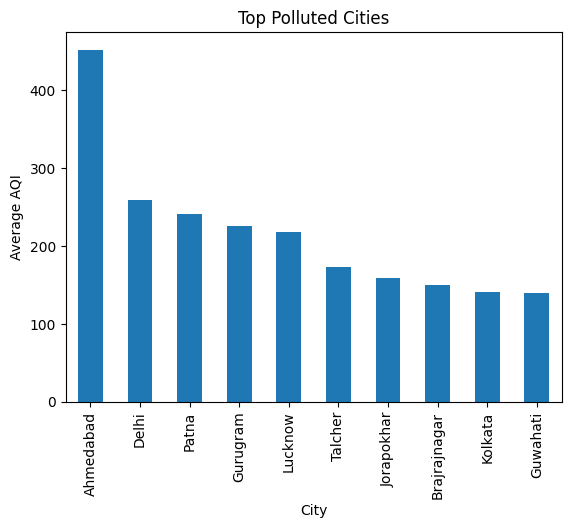

In [71]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('city_day.csv')

city_avg = (
    df.groupby("City")
    ["AQI"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

city_avg.plot(kind="bar")
plt.title("Top Polluted Cities")
plt.ylabel("Average AQI")
plt.show()

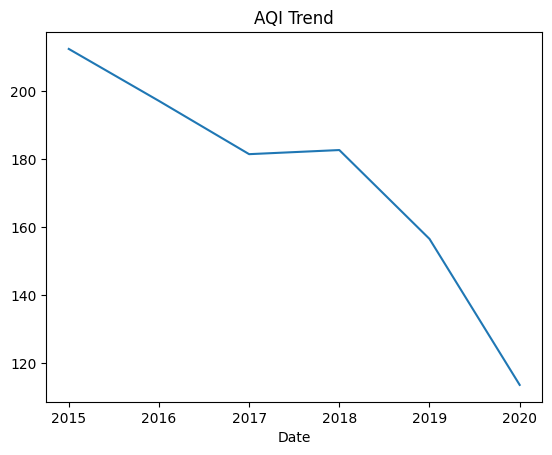

In [72]:
df["Date"] = pd.to_datetime(
df["Date"]
)

monthly = (
df.groupby(
df["Date"].dt.year
)
["AQI"]
.mean()
)

monthly.plot()

plt.title(
"AQI Trend"
)

plt.show()

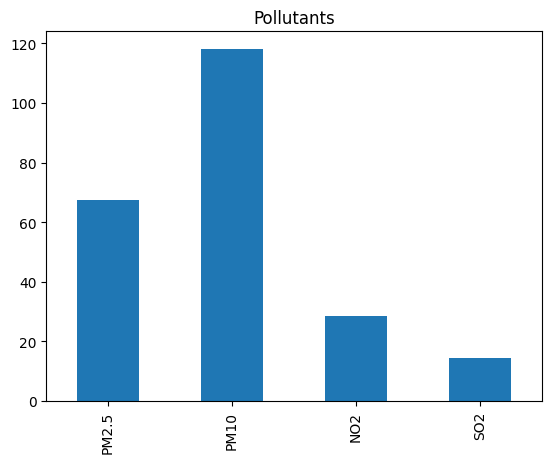

In [73]:
pollutants = [
"PM2.5",
"PM10",
"NO2",
"SO2"
]

df[
pollutants
].mean().plot(
kind="bar"
)

plt.title(
"Pollutants"
)

plt.show()

In [74]:
clean = (
df.groupby(
"City"
)["AQI"]
.mean()
.sort_values()
.head(10)
)

print(clean)

City
Aizawl                 34.765766
Shillong               53.795122
Coimbatore             73.023256
Thiruvananthapuram     75.878327
Ernakulam              92.359477
Bengaluru              94.318325
Amaravati              95.299643
Chandigarh             96.498328
Kochi                 104.284810
Mumbai                105.352258
Name: AQI, dtype: float64


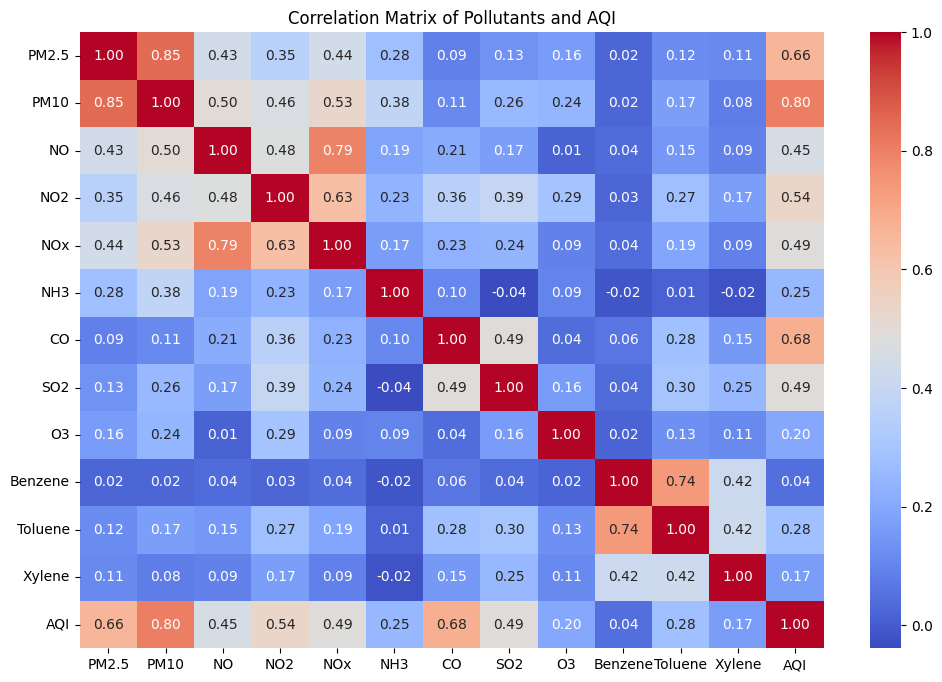

            PM2.5      PM10        NO       NO2       NOx       NH3        CO  \
PM2.5    1.000000  0.846498  0.433491  0.350709  0.436792  0.275086  0.089912   
PM10     0.846498  1.000000  0.502349  0.464380  0.527768  0.376816  0.112588   
NO       0.433491  0.502349  1.000000  0.478070  0.794890  0.185621  0.212607   
NO2      0.350709  0.464380  0.478070  1.000000  0.627627  0.234938  0.356521   
NOx      0.436792  0.527768  0.794890  0.627627  1.000000  0.166224  0.226992   
NH3      0.275086  0.376816  0.185621  0.234938  0.166224  1.000000  0.104891   
CO       0.089912  0.112588  0.212607  0.356521  0.226992  0.104891  1.000000   
SO2      0.132325  0.256974  0.170322  0.392233  0.238397 -0.038998  0.489697   
O3       0.161238  0.244919  0.014580  0.293349  0.093170  0.094972  0.041736   
Benzene  0.023911  0.022265  0.035771  0.025260  0.039121 -0.015650  0.061861   
Toluene  0.117080  0.169335  0.150857  0.273926  0.189386  0.013227  0.277904   
Xylene   0.114579  0.081700 

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.select_dtypes(include=['number']).corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Pollutants and AQI')
plt.show()

print(corr)